In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

from rasterio.windows import Window, bounds as granice_okna

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 11})

ZDJECIE = Path("data/tapias_ortofoto.tif")          # <- tu możesz podstawić własne zdjęcie
KATALOG = Path("results")
KATALOG.mkdir(parents=True, exist_ok=True)

WYNIK = KATALOG / "okna_i_kafelki"
WYNIK.mkdir(parents=True, exist_ok=True)

In [18]:
okno = Window(col_off=900, row_off=900, width=400, height=400)
with rasterio.open(ZDJECIE) as src:
    fragment = src.read(window=okno)
    T, T_fragmentu = src.transform, src.window_transform(okno)
    print(fragment.shape) 
    print(T_fragmentu)

(3, 400, 400)
| 0.12, 0.00, 461085.91|
| 0.00,-0.12, 492338.15|
| 0.00, 0.00, 1.00|


In [12]:
print(T_fragmentu * (0, 0), T * (900, 900))

(461085.91405118065, 492338.1528246257) (461085.91405118065, 492338.1528246257)


In [14]:
with rasterio.open(ZDJECIE) as src:
    crs, T, bounds, gsd = src.crs, src.transform, src.bounds, src.res[0]   # zapamiętujemy na później
    print("format (sterownik):   ", src.driver)
    print("rozmiar (kol × wier.):", src.width, "×", src.height)
    print("kanały, typ danych:   ", src.count, ",", src.dtypes[0])
    print("układ (CRS):          ", f"EPSG:{crs.to_epsg()}", "| metryczny:", crs.is_projected)
    print("rozmiar piksela (GSD):", f"{gsd:.5f} m")
    print("zasięg (bounds):      ", bounds)
    print("NoData:               ", src.nodata)
    szer_m, wys_m = src.width * gsd, src.height * gsd

print(f"zasięg w terenie:      {szer_m:.1f} × {wys_m:.1f} m = {szer_m * wys_m / 1e4:.2f} ha")

format (sterownik):    GTiff
rozmiar (kol × wier.): 1731 × 1731
kanały, typ danych:    3 , uint8
układ (CRS):           EPSG:32618 | metryczny: True
rozmiar piksela (GSD): 0.12000 m
zasięg (bounds):       BoundingBox(left=460977.91405118065, bottom=492238.43282462575, right=461185.6340511806, top=492446.1528246257)
NoData:                0.0
zasięg w terenie:      207.7 × 207.7 m = 4.31 ha


In [15]:


with rasterio.open(ZDJECIE) as src:
    dane = src.read()                                       # rasterio: (kanały, wiersze, kolumny)
    maska_rasterio = src.dataset_mask() > 0                 # ważne piksele według GDAL-a (255 → True)
    maska_kanalu_1 = src.read_masks(1) > 0                  # maska samego kanału 1 (R)
rgb = np.moveaxis(dane, 0, -1)                              # (wiersze, kolumny, kanały)
waznie = ~(rgb == 0).all(axis=-1)                           # ważny = choć jeden kanał różny od 0

print("kształty:", dane.shape, "→", rgb.shape)
print(f"NoData: {1 - waznie.mean():.1%} kadru | ważne: {waznie.sum():,} px = {waznie.sum() * gsd**2 / 1e4:.2f} ha")

jasnosc = rgb.astype(np.float32).mean(axis=-1)
print(f"średnia jasność: wszystkie piksele {jasnosc.mean():.1f} | tylko ważne {jasnosc[waznie].mean():.1f}")

print("dataset_mask() == waznie:", np.array_equal(maska_rasterio, waznie))
print("read_masks(1) == waznie: ", np.array_equal(maska_kanalu_1, waznie), "| ważnych pikseli z R = 0:", (waznie & ~maska_kanalu_1).sum())
print("ważnych pikseli z zerem w którymkolwiek kanale:", (waznie & (rgb == 0).any(axis=-1)).sum())

kształty: (3, 1731, 1731) → (1731, 1731, 3)
NoData: 7.6% kadru | ważne: 2,768,785 px = 3.99 ha
średnia jasność: wszystkie piksele 101.8 | tylko ważne 110.1
dataset_mask() == waznie: True
read_masks(1) == waznie:  False | ważnych pikseli z R = 0: 8
ważnych pikseli z zerem w którymkolwiek kanale: 137


In [19]:
import pandas as pd

okno = Window(col_off=900, row_off=900, width=400, height=400)
with rasterio.open(ZDJECIE) as src:
    fragment = src.read(window=okno)                                   # czyta z dysku tylko ten fragment
    T_fragmentu = src.window_transform(okno)
print("kształt fragmentu:", fragment.shape)
print("lewy górny róg fragmentu:", T_fragmentu * (0, 0), "| T * (900, 900):", T * (900, 900))


kształt fragmentu: (3, 400, 400)
lewy górny róg fragmentu: (461085.91405118065, 492338.1528246257) | T * (900, 900): (461085.91405118065, 492338.1528246257)


In [20]:

K = 256                                                                # bok kafelka [px]
wiersze = []
for w in range(0, rgb.shape[0] - K + 1, K):                            # tylko pełne kafelki
    for k in range(0, rgb.shape[1] - K + 1, K):
        wiersze.append({"wiersz": w, "kolumna": k, "nodata": 1 - waznie[w:w + K, k:k + K].mean()})
kafelki = pd.DataFrame(wiersze)

n_bok = rgb.shape[0] // K
print(f"kafelków {K}×{K}: {len(kafelki)} ({n_bok}×{n_bok}), bok kafelka {K * gsd:.1f} m, poza kafelkami zostaje {rgb.shape[0] - n_bok * K} px z prawej i z dołu")
print("w 100% ważnych:", (kafelki.nodata == 0).sum(), "| z jakimkolwiek NoData:", (kafelki.nodata > 0).sum(), "| z > 50% NoData:", (kafelki.nodata > 0.5).sum())


kafelków 256×256: 36 (6×6), bok kafelka 30.7 m, poza kafelkami zostaje 195 px z prawej i z dołu
w 100% ważnych: 28 | z jakimkolwiek NoData: 8 | z > 50% NoData: 4


In [21]:
kafelki

,wiersz,kolumna,nodata
0,0,0,1.000000
1,0,256,0.651581
2,0,512,0.000000
3,0,768,0.000000
4,0,1024,0.003479
5,0,1280,0.003906
6,256,0,0.988998
7,256,256,0.193939
8,256,512,0.000000
9,256,768,0.000000


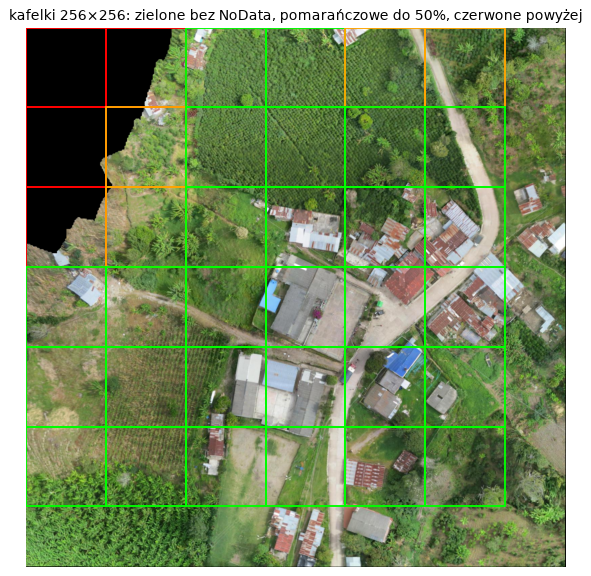

In [22]:

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(rgb)
for t in kafelki.itertuples():
    kolor = "lime" if t.nodata == 0 else ("orange" if t.nodata <= 0.5 else "red")
    ax.add_patch(plt.Rectangle((t.kolumna, t.wiersz), K, K, fill=False, edgecolor=kolor, linewidth=1.5))
ax.set_title("kafelki 256×256: zielone bez NoData, pomarańczowe do 50%, czerwone powyżej")
ax.axis("off")
plt.tight_layout()

In [23]:
WYNIKI = KATALOG / "okna_i_kafelki"

def zapisz_jpg(rgb: np.ndarray, kafelki: pd.DataFrame) -> None:
    katalog = WYNIKI / "kafelki_jpg"
    katalog.mkdir(exist_ok=True)
    wazne = kafelki[kafelki.nodata == 0]
    for t in wazne.itertuples():
        kafelek = rgb[t.wiersz:t.wiersz + K, t.kolumna:t.kolumna + K]  # numpy: najpierw wiersz
        Image.fromarray(kafelek).save(katalog / f"kafelek_w{t.wiersz:04d}_k{t.kolumna:04d}.jpg", quality=JPG_JAKOSC)
    rozmiar = sum(p.stat().st_size for p in katalog.glob("*.jpg"))
    print(f"[jpg] zapisano {len(wazne)} plików do {katalog.relative_to(KATALOG)} ({rozmiar / 1e6:.1f} MB)")



In [26]:
from PIL import Image
JPG_JAKOSC = 95

zapisz_jpg(rgb, kafelki)

[jpg] zapisano 28 plików do okna_i_kafelki/kafelki_jpg (0.7 MB)
